In [1]:
# ==========================================================
# Google Colab script to generate a Venn diagram of unique
# molecule identifiers for RECAP, BRICS, and CRUSH
# ==========================================================

import pandas as pd
import matplotlib.pyplot as plt
from google.colab import files

In [2]:
# ----------------------------------------------------------
# 1. Install required package (only needed once per session)
# ----------------------------------------------------------
!pip install matplotlib-venn

from matplotlib_venn import venn3

In [3]:
# ----------------------------------------------------------
# 2. Upload CSV file
# ----------------------------------------------------------
uploaded = files.upload()
csv_filename = list(uploaded.keys())[0]

Saving fragments_with_umap.csv to fragments_with_umap.csv


In [4]:
# ----------------------------------------------------------
# 2. Load CSV (adjust separator if needed)
# ----------------------------------------------------------
df = pd.read_csv(csv_filename, sep=",")

In [5]:
df.head()

,Identifier,Original_SMILES,Fragment_SMILES,Rule,Mode,UMAP_1,UMAP_2
0,AP00195,[2H]C([2H])([2H])C(CC(C(NC1CSSCC(C(NC(C(NCC(NC...,[3*]C(=O)C(CC(C([2H])([2H])[2H])C([2H])([2H])[...,Amide,RECAP,4.704682,6.208411
1,AP00195,[2H]C([2H])([2H])C(CC(C(NC1CSSCC(C(NC(C(NCC(NC...,[4*]NC1CSSCC(C(=O)NC(C(=O)NCC(=O)NC(CCC[NH+]=C...,Amide,RECAP,11.168615,12.146476
2,AP00195,[2H]C([2H])([2H])C(CC(C(NC1CSSCC(C(NC(C(NCC(NC...,[3*]C(=O)C(CCC[NH+]=C(N)N)NC(=O)CNC(=O)CNC(=O)...,Amide,RECAP,4.709050,6.204665
3,AP00195,[2H]C([2H])([2H])C(CC(C(NC1CSSCC(C(NC(C(NCC(NC...,[3*]C(=O)C(CC(C([2H])([2H])[2H])C([2H])([2H])[...,Amide,RECAP,-4.342031,-3.659706
4,AP00195,[2H]C([2H])([2H])C(CC(C(NC1CSSCC(C(NC(C(NCC(NC...,[3*]C(=O)CNC(=O)CNC(=O)C([NH3+])CCC[NH+]=C(N)N,Amide,RECAP,4.735446,6.182208


In [6]:
#-----------------
# 4. Sanity check
# ----------------------------------------------------------
required_columns = {"Identifier", "Mode"}
missing = required_columns - set(df.columns)
if missing:
    raise ValueError(f"Missing required columns: {missing}")

In [7]:
# ----------------------------------------------------------
# 5. Build sets of UNIQUE identifiers per rule
# ----------------------------------------------------------
recap_set  = set(df.loc[df["Mode"] == "RECAP", "Identifier"].unique())
brics_set  = set(df.loc[df["Mode"] == "BRICS", "Identifier"].unique())
crush_set  = set(df.loc[df["Mode"] == "CRUSH", "Identifier"].unique())

/usr/local/lib/python3.12/dist-packages/matplotlib_venn/layout/venn3/pairwise.py:169: UserWarning: Bad circle positioning.
  warnings.warn("Bad circle positioning.")


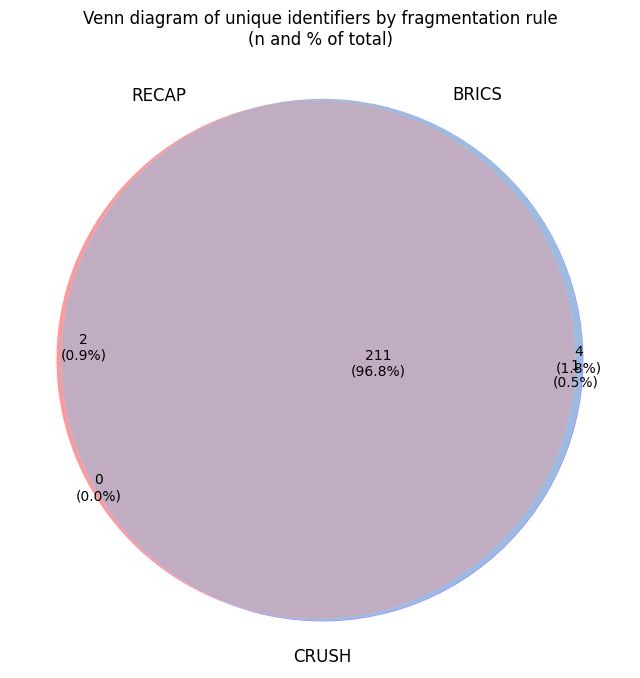

In [8]:
# ----------------------------------------------------------
# 5. Compute Venn regions explicitly
# ----------------------------------------------------------
only_recap  = recap_set - brics_set - crush_set
only_brics  = brics_set - recap_set - crush_set
only_crush  = crush_set - recap_set - brics_set

recap_brics = (recap_set & brics_set) - crush_set
recap_crush = (recap_set & crush_set) - brics_set
brics_crush = (brics_set & crush_set) - recap_set

all_three   = recap_set & brics_set & crush_set

total_ids = len(recap_set | brics_set | crush_set)

# ----------------------------------------------------------
# 6. Create Venn diagram
# ----------------------------------------------------------
plt.figure(figsize=(8, 8))
v = venn3(
    [recap_set, brics_set, crush_set],
    set_labels=("RECAP", "BRICS", "CRUSH")
)

# ----------------------------------------------------------
# 7. Label regions with n and %
# ----------------------------------------------------------
def label_text(n, total):
    pct = (n / total) * 100 if total > 0 else 0
    return f"{n}\n({pct:.1f}%)"

region_counts = {
    "100": len(only_recap),
    "010": len(only_brics),
    "001": len(only_crush),
    "110": len(recap_brics),
    "101": len(recap_crush),
    "011": len(brics_crush),
    "111": len(all_three),
}

for region, count in region_counts.items():
    label = v.get_label_by_id(region)
    if label:
        label.set_text(label_text(count, total_ids))

plt.title("Venn diagram of unique identifiers by fragmentation rule\n(n and % of total)")
plt.show()